In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
scan_folder = "/scratch/zhaoyuha/Datas/EQuantum_data/squaregate_center/setup/setup_ae7d9fc59f6721d485f0e595c14ca989/fsc_logs_scan_2"

In [3]:
FNAME_RE = re.compile(r"phi_([0-9eE+\-\.]+)_Vbg_([0-9eE+\-\.]+)\.npz$")

def parse_filename(fname):
    m = FNAME_RE.match(os.path.basename(fname))
    if m is None:
        return None
    return float(m.group(1)), float(m.group(2))

def load_static_qsites(scan_folder):
    static_path = os.path.join(scan_folder, "run_static.npz")
    if not os.path.exists(static_path):
        return None
    data = np.load(static_path, allow_pickle=True)
    static_data = data["static_data"][0]
    if "Qsites" not in static_data:
        return None
    return np.asarray(static_data["Qsites"], dtype=int)

def ensure_q_local(arr, qsites):
    arr = np.asarray(arr, dtype=float)

    if arr.ndim != 1:
        raise ValueError(f"Expected 1D array, got shape {arr.shape}")

    if len(arr) == len(qsites):
        return arr

    if len(arr) >= np.max(qsites) + 1:
        return arr[qsites]

    raise ValueError(
        f"Cannot map array of length {len(arr)} to Qsites of length {len(qsites)}"
    )

In [8]:
def ldos_at_energy_for_snapshot(npz_path, qsites_static=None):
    data = np.load(npz_path, allow_pickle=True)

    if "ildos" not in data:
        raise ValueError(f"No 'ildos' in {npz_path}")
    if "Ui" not in data:
        raise ValueError(f"No 'Ui' in {npz_path}")

    ildos = data["ildos"]

    if "Qsites" in data:
        qsites = np.asarray(data["Qsites"], dtype=int)
    elif qsites_static is not None:
        qsites = np.asarray(qsites_static, dtype=int)
    else:
        raise ValueError(f"No Qsites found in {npz_path} or run_static.npz")

    Ui_local = ensure_q_local(data["Ui"], qsites)

    n_q = len(qsites)
    if len(ildos) != n_q:
        raise ValueError(
            f"ildos length {len(ildos)} does not match len(Qsites)={n_q} in {npz_path}"
        )

    rho0 = np.full(n_q, np.nan, dtype=float)
    rhoUi = np.full(n_q, np.nan, dtype=float)

    for i in range(n_q):
        E = np.asarray(ildos[i][0], dtype=float)
        rho = np.asarray(ildos[i][1], dtype=float)

        if E.ndim != 1 or rho.ndim != 1 or len(E) < 2 or len(E) != len(rho):
            continue

        rho0[i] = np.interp(0.0, E, rho, left=np.nan, right=np.nan)
        rhoUi[i] = np.interp(Ui_local[i], E, rho, left=np.nan, right=np.nan)

    qprime_mask = None
    if "Qprime" in data:
        Qprime = np.asarray(data["Qprime"], dtype=int)
        qprime_mask = np.isin(qsites, Qprime)

    return {
        "qsites": qsites,
        "Ui_local": Ui_local,
        "rho0": rho0,
        "rhoUi": rhoUi,
        "qprime_mask": qprime_mask,
    }

In [4]:
def reduce_ldos(snapshot_dict, mode="mean_qprime", site_id=None):
    rho0 = snapshot_dict["rho0"]
    rhoUi = snapshot_dict["rhoUi"]
    qsites = snapshot_dict["qsites"]
    qprime_mask = snapshot_dict["qprime_mask"]

    if mode == "site":
        if site_id is None:
            raise ValueError("mode='site' requires site_id")
        idx = np.where(qsites == site_id)[0]
        if len(idx) == 0:
            return np.nan, np.nan
        i = idx[0]
        return rho0[i], rhoUi[i]

    if mode == "mean_all":
        return np.nanmean(rho0), np.nanmean(rhoUi)

    if mode == "max_all":
        return np.nanmax(rho0), np.nanmax(rhoUi)

    if qprime_mask is None:
        if mode == "mean_qprime":
            return np.nanmean(rho0), np.nanmean(rhoUi)
        if mode == "max_qprime":
            return np.nanmax(rho0), np.nanmax(rhoUi)

    rho0_q = rho0[qprime_mask]
    rhoUi_q = rhoUi[qprime_mask]

    if rho0_q.size == 0:
        return np.nan, np.nan

    if mode == "mean_qprime":
        return np.nanmean(rho0_q), np.nanmean(rhoUi_q)

    if mode == "max_qprime":
        return np.nanmax(rho0_q), np.nanmax(rhoUi_q)

    raise ValueError(f"Unknown mode: {mode}")

In [5]:
def build_maps(scan_folder, mode="mean_qprime", site_id=None):
    qsites_static = load_static_qsites(scan_folder)

    files = []
    for fname in os.listdir(scan_folder):
        if not fname.endswith(".npz"):
            continue
        if fname == "run_static.npz":
            continue
        parsed = parse_filename(fname)
        if parsed is None:
            continue
        files.append((fname, *parsed))

    if len(files) == 0:
        raise RuntimeError(f"No scan npz files found in {scan_folder}")

    phis = sorted({phi for _, phi, _ in files})
    vbgs = sorted({vbg for _, _, vbg in files})

    phi_to_i = {v: i for i, v in enumerate(phis)}
    vbg_to_j = {v: j for j, v in enumerate(vbgs)}

    map_rho0 = np.full((len(vbgs), len(phis)), np.nan, dtype=float)
    map_rhoUi = np.full((len(vbgs), len(phis)), np.nan, dtype=float)

    for fname, phi, vbg in files:
        full_path = os.path.join(scan_folder, fname)
        snap = ldos_at_energy_for_snapshot(full_path, qsites_static=qsites_static)
        val0, valUi = reduce_ldos(snap, mode=mode, site_id=site_id)

        j = vbg_to_j[vbg]
        i = phi_to_i[phi]
        map_rho0[j, i] = val0
        map_rhoUi[j, i] = valUi

    return np.array(phis), np.array(vbgs), map_rho0, map_rhoUi

In [30]:
def plot_ldos_maps(phis, vbgs, map_rho0, map_rhoUi, mode_label="mean_qprime"):
    extent = [phis.min(), phis.max(), vbgs.min(), vbgs.max()]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    im0 = axes[0].imshow(
        map_rho0,
        origin="lower",
        aspect="auto",
        extent=extent,
    )
    axes[0].set_title(f"LDOS@0 ({mode_label})")
    axes[0].set_xlabel("phi")
    axes[0].set_ylabel("backgate voltage")
    plt.colorbar(im0, ax=axes[0], pad=0.02)

    im1 = axes[1].imshow(
        map_rhoUi,
        origin="lower",
        aspect="auto",
        extent=extent,
    )
    axes[1].set_title(f"LDOS@Ui ({mode_label})")
    axes[1].set_xlabel("phi")
    axes[1].set_ylabel("backgate voltage")
    plt.colorbar(im1, ax=axes[1], pad=0.02)

    plt.show()

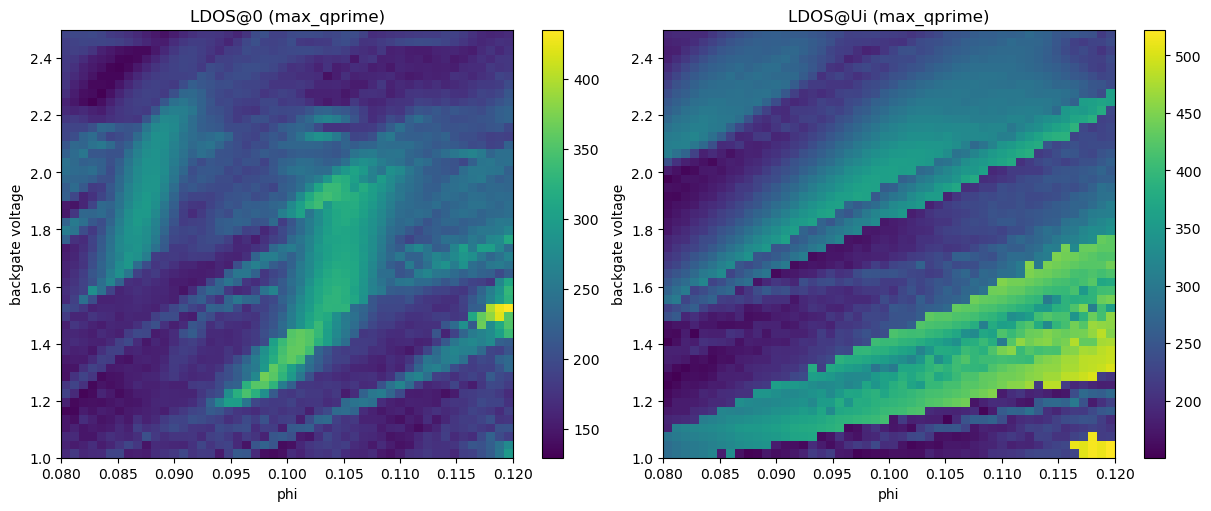

In [31]:
mode = "max_qprime"
site_id = None

phis, vbgs, map_rho0, map_rhoUi = build_maps(
    scan_folder,
    mode=mode,
    site_id=site_id,
)

plot_ldos_maps(phis, vbgs, map_rho0, map_rhoUi, mode_label=mode)

In [17]:
def linecut_mask_qsites(qsites, qsites_static, coords_q, y0=0.0, dy=0.02):
    """
    Return mask on Qsites selecting sites near the horizontal line y = y0.

    Parameters
    ----------
    qsites : array-like
        Qsites used in the snapshot.
    qsites_static : array-like
        Qsites from run_static.npz, matching coords_q ordering.
    coords_q : array-like, shape (Nq, 2)
        Quantum coordinates from run_static.npz.
    y0 : float
        Center of the line cut.
    dy : float
        Thickness of the cut band.

    Returns
    -------
    mask : ndarray of bool, shape (len(qsites),)
    """
    qsites = np.asarray(qsites, dtype=int)
    qsites_static = np.asarray(qsites_static, dtype=int)
    coords_q = np.asarray(coords_q, dtype=float)

    static_map = {sid: i for i, sid in enumerate(qsites_static)}

    mask = np.zeros(len(qsites), dtype=bool)
    for i, sid in enumerate(qsites):
        if sid not in static_map:
            continue
        j = static_map[sid]
        y = coords_q[j, 1]
        mask[i] = (abs(y - y0) <= dy / 2)

    return mask

In [18]:
def load_static_quantum_geometry(scan_folder):
    static_path = os.path.join(scan_folder, "run_static.npz")
    if not os.path.exists(static_path):
        raise FileNotFoundError(f"Missing run_static.npz in {scan_folder}")

    data = np.load(static_path, allow_pickle=True)
    static_data = data["static_data"][0]

    qsites = np.asarray(static_data["Qsites"], dtype=int)
    coords_q = np.asarray(static_data["coords_q"], dtype=float)

    return qsites, coords_q

In [19]:
def reduce_ldos_linecut(snapshot_dict, qsites_static, coords_q, y0=0.0, dy=0.02,
                        quantity="sum", use_qprime=False):
    """
    Reduce LDOS over a horizontal line cut near y=y0.

    Parameters
    ----------
    snapshot_dict : dict
        Output of ldos_at_energy_for_snapshot(...)
    qsites_static, coords_q :
        From run_static.npz
    y0 : float
        Line-cut center
    dy : float
        Cut thickness
    quantity : {"sum", "mean"}
        Whether to sum or average along the line cut
    use_qprime : bool
        If True, restrict line-cut sites further to Qprime
    """
    qsites = snapshot_dict["qsites"]
    rho0 = snapshot_dict["rho0"]
    rhoUi = snapshot_dict["rhoUi"]
    qprime_mask = snapshot_dict["qprime_mask"]

    mask_line = linecut_mask_qsites(qsites, qsites_static, coords_q, y0=y0, dy=dy)

    if use_qprime and qprime_mask is not None:
        mask_line = mask_line & qprime_mask

    rho0_sel = rho0[mask_line]
    rhoUi_sel = rhoUi[mask_line]

    if rho0_sel.size == 0:
        return np.nan, np.nan, 0

    if quantity == "sum":
        return np.nansum(rho0_sel), np.nansum(rhoUi_sel), int(mask_line.sum())
    elif quantity == "mean":
        return np.nanmean(rho0_sel), np.nanmean(rhoUi_sel), int(mask_line.sum())
    else:
        raise ValueError("quantity must be 'sum' or 'mean'")

In [20]:
def build_maps_linecut(scan_folder, y0=0.0, dy=0.02, quantity="sum", use_qprime=False):
    qsites_static, coords_q = load_static_quantum_geometry(scan_folder)

    files = []
    for fname in os.listdir(scan_folder):
        if not fname.endswith(".npz"):
            continue
        if fname == "run_static.npz":
            continue
        parsed = parse_filename(fname)
        if parsed is None:
            continue
        files.append((fname, *parsed))

    if len(files) == 0:
        raise RuntimeError(f"No scan npz files found in {scan_folder}")

    phis = sorted({phi for _, phi, _ in files})
    vbgs = sorted({vbg for _, _, vbg in files})

    phi_to_i = {v: i for i, v in enumerate(phis)}
    vbg_to_j = {v: j for j, v in enumerate(vbgs)}

    map_rho0 = np.full((len(vbgs), len(phis)), np.nan, dtype=float)
    map_rhoUi = np.full((len(vbgs), len(phis)), np.nan, dtype=float)
    map_nsites = np.zeros((len(vbgs), len(phis)), dtype=int)

    for fname, phi, vbg in files:
        full_path = os.path.join(scan_folder, fname)
        snap = ldos_at_energy_for_snapshot(full_path, qsites_static=qsites_static)

        val0, valUi, nsites = reduce_ldos_linecut(
            snap,
            qsites_static=qsites_static,
            coords_q=coords_q,
            y0=y0,
            dy=dy,
            quantity=quantity,
            use_qprime=use_qprime,
        )

        j = vbg_to_j[vbg]
        i = phi_to_i[phi]
        map_rho0[j, i] = val0
        map_rhoUi[j, i] = valUi
        map_nsites[j, i] = nsites

    return np.array(phis), np.array(vbgs), map_rho0, map_rhoUi, map_nsites

In [26]:
from matplotlib.colors import LogNorm

def plot_linecut_maps(phis, vbgs, map_rho0, map_rhoUi, y0=0.0, dy=0.02, quantity="sum", use_qprime=False):
    extent = [phis.min(), phis.max(), vbgs.min(), vbgs.max()]
    suffix = f"{quantity} on x-line cut at y={y0} ± {dy/2}"
    if use_qprime:
        suffix += " (Qprime only)"

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    eps0 = np.nanmin(map_rho0[map_rho0 > 0]) if np.any(map_rho0 > 0) else 1e-12
    eps1 = np.nanmin(map_rhoUi[map_rhoUi > 0]) if np.any(map_rhoUi > 0) else 1e-12

    im0 = axes[0].imshow(
        map_rho0,
        origin="lower",
        aspect="auto",
        extent=extent,
        norm=LogNorm(vmin=eps0, vmax=np.nanmax(map_rho0)),
    )
    axes[0].set_title(f"LDOS@0: {suffix}")
    axes[0].set_xlabel("phi")
    axes[0].set_ylabel("backgate voltage")
    plt.colorbar(im0, ax=axes[0], pad=0.02)

    im1 = axes[1].imshow(
        map_rhoUi,
        origin="lower",
        aspect="auto",
        extent=extent,
        norm=LogNorm(vmin=eps1, vmax=np.nanmax(map_rhoUi)),
    )
    axes[1].set_title(f"LDOS@Ui: {suffix}")
    axes[1].set_xlabel("phi")
    axes[1].set_ylabel("backgate voltage")
    plt.colorbar(im1, ax=axes[1], pad=0.02)

    plt.show()

In [28]:
y0 = 0.4
dy = 0.02          # thickness of the cut band
quantity = "sum"   # or "mean"
use_qprime = False # set True if you only want active-region sites

phis, vbgs, map_rho0_cut, map_rhoUi_cut, map_nsites_cut = build_maps_linecut(
    scan_folder,
    y0=y0,
    dy=dy,
    quantity=quantity,
    use_qprime=use_qprime,
)



/tmp/ipykernel_547669/359563992.py:19: RuntimeWarning: All-NaN slice encountered
  norm=LogNorm(vmin=eps0, vmax=np.nanmax(map_rho0)),


ValueError: Invalid vmin or vmax

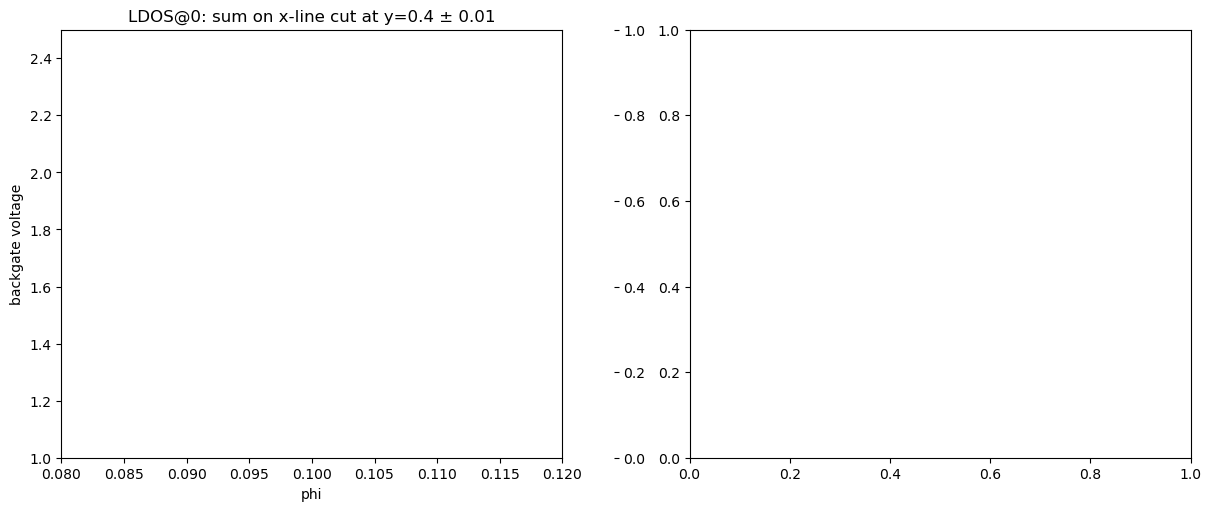

In [29]:
plot_linecut_maps(
    phis,
    vbgs,
    map_rho0_cut,
    map_rhoUi_cut,
    y0=y0,
    dy=dy,
    quantity=quantity,
    use_qprime=use_qprime,
)

In [10]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [11]:
csv_path = os.path.join(scan_folder, "scan_progress.csv")

scan_df = pd.read_csv(csv_path)
scan_df

,timestamp,phi,Vbg,outfile,converged,runtime_sec,iter_qprime,iter_poisson,iter_quantum,qprime_len,ui_maxdiff,ni_maxdiff,ildos_maxdiff,status,restart_mode
0,2026-03-28T12:56:11.758520,0.080000,1.000000,phi_0.0800_Vbg_1.0000.npz,True,432.540530,8,4,7,3440,0.000251,0.002763,1.057288e-11,ok,fresh
1,2026-03-28T12:59:55.492464,0.080000,1.030612,phi_0.0800_Vbg_1.0306.npz,True,223.733527,8,4,7,3456,0.000299,0.002371,1.386979e-11,ok,warm
2,2026-03-28T13:03:38.811533,0.080000,1.061224,phi_0.0800_Vbg_1.0612.npz,True,223.318710,8,4,7,3466,0.000282,0.001959,2.103206e-11,ok,warm
3,2026-03-28T13:07:21.311956,0.080000,1.091837,phi_0.0800_Vbg_1.0918.npz,True,222.500129,7,3,7,3476,0.000346,0.001977,3.751666e-12,ok,warm
4,2026-03-28T13:10:55.345849,0.080000,1.122449,phi_0.0800_Vbg_1.1224.npz,True,214.033600,7,3,7,3483,0.000349,0.002135,3.012701e-12,ok,warm
5,2026-03-28T13:14:11.362903,0.080000,1.153061,phi_0.0800_Vbg_1.1531.npz,True,196.016632,7,3,7,3489,0.000367,0.001774,1.512035e-11,ok,warm
6,2026-03-28T13:17:22.356327,0.080000,1.183673,phi_0.0800_Vbg_1.1837.npz,True,190.993071,7,3,7,3500,0.000339,0.001785,1.261924e-11,ok,warm
7,2026-03-28T13:20:37.155399,0.080000,1.214286,phi_0.0800_Vbg_1.2143.npz,True,194.798808,7,3,7,3513,0.000342,0.001365,6.252776e-12,ok,warm
8,2026-03-28T13:23:49.885344,0.080000,1.244898,phi_0.0800_Vbg_1.2449.npz,True,192.729699,7,3,7,3526,0.000337,0.001624,1.688250e-11,ok,warm
9,2026-03-28T13:27:12.017974,0.080000,1.275510,phi_0.0800_Vbg_1.2755.npz,True,202.132400,7,3,7,3538,0.000345,0.001232,9.322321e-12,ok,warm


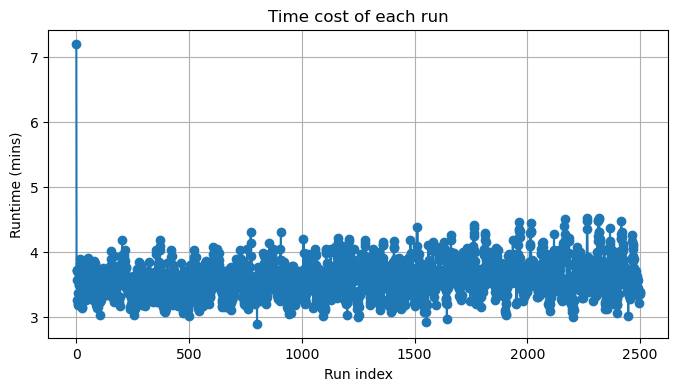

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt


csv_path = os.path.join(scan_folder, "scan_progress.csv")

scan_df = pd.read_csv(csv_path)

plt.figure(figsize=(8, 4))
plt.plot(scan_df["runtime_sec"].to_numpy()/60, marker="o")
plt.xlabel("Run index")
plt.ylabel("Runtime (mins)")
plt.title("Time cost of each run")
plt.grid(True)
plt.show()

In [13]:
np.sum(scan_df['runtime_sec'].to_numpy())/60/100

89.61726523678743